In [424]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import seaborn as sns
import requests
# prison path from folder prison data
prison_path = Path('../data/prison data/crim_pris_age_linear_2_0.csv')
#import dataset
prison_data = pd.read_csv(prison_path)
prison_data.tail(5)

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,age,Age class,sex,Sex,unit,...,geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
10525,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,TOTAL,Total,T,Total,P_HTHAB,...,XK,Kosovo*,2016,NaN,93.02,NaN,NaN,NaN,NaN,NaN
10526,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,TOTAL,Total,T,Total,P_HTHAB,...,XK,Kosovo*,2017,NaN,95.82,NaN,NaN,NaN,NaN,NaN
10527,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,TOTAL,Total,T,Total,P_HTHAB,...,XK,Kosovo*,2018,NaN,87.13,NaN,NaN,NaN,NaN,NaN
10528,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,TOTAL,Total,T,Total,P_HTHAB,...,XK,Kosovo*,2019,NaN,100.58,NaN,NaN,NaN,NaN,NaN
10529,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,TOTAL,Total,T,Total,P_HTHAB,...,XK,Kosovo*,2020,NaN,78.33,NaN,NaN,NaN,NaN,NaN


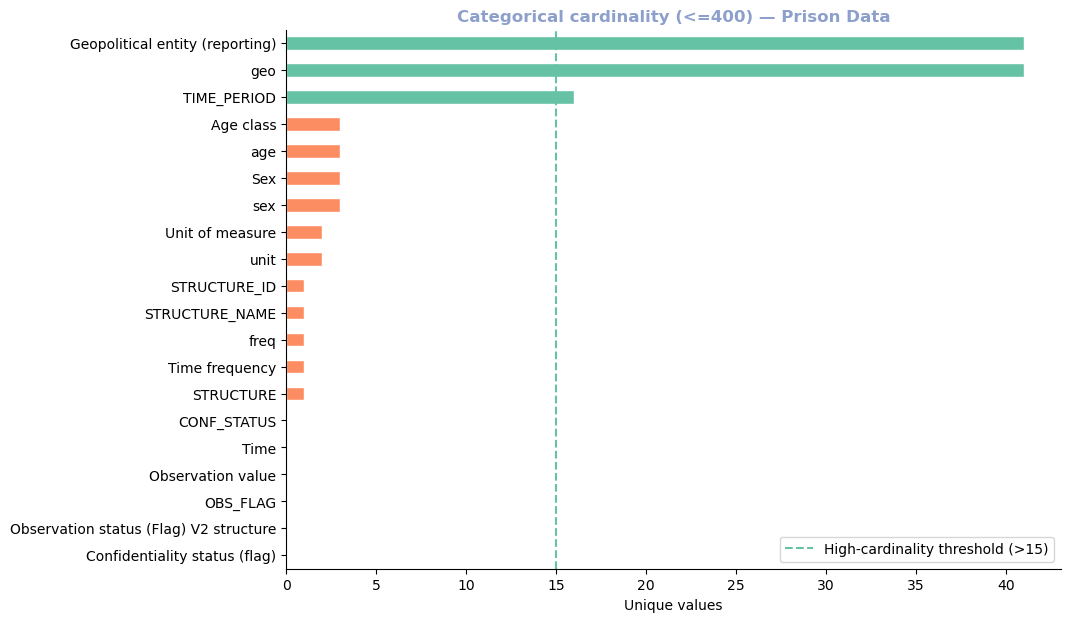

HIGH-CARDINALITY features (excluded from chart):
    'OBS_VALUE': 6564 unique values — needs grouping/target encoding

  Reviewing unique values (Prison Data):
  'Confidentiality status (flag)' (0 values): []

  'Observation status (Flag) V2 structure' (0 values): []

  'OBS_FLAG' (0 values): []

  'Observation value' (0 values): []

  'Time' (0 values): []

  'CONF_STATUS' (0 values): []

  'STRUCTURE' (1 values): ['dataflow']

  'Time frequency' (1 values): ['Annual']

  'freq' (1 values): ['A']

  'STRUCTURE_NAME' (1 values): ['Prisoners by age and sex']

  'STRUCTURE_ID' (1 values): ['ESTAT:CRIM_PRIS_AGE(1.0)']

  'unit' (2 values): ['NR', 'P_HTHAB']

  'Unit of measure' (2 values): ['Number', 'Per hundred thousand inhabitants']

  'sex' (3 values): ['F', 'M', 'T']

  'Sex' (3 values): ['Females', 'Males', 'Total']

  'age' (3 values): ['ADULT', 'JUVENILE', 'TOTAL']

  'Age class' (3 values): ['Adult', 'Juvenile', 'Total']

  'TIME_PERIOD' (16 values): ['2008', '2009', '2010', '201

In [425]:
# cardinality of the dataset
YEARS = range(2008, 2024)
PALETTE = sns.color_palette("Set2")
CORAL, STEEL, NAVY = PALETTE[0], PALETTE[1], PALETTE[2]
def inspect_categorical(df, dataset_name):
    """Separate low- and high-cardinality categoricals, plot the former, list the latter."""
    cat_cols = df.select_dtypes(include=["object", "category", "bool", "int64", "float64"]).columns
    if len(cat_cols) == 0:
        print(f"  No categorical columns in {dataset_name}.")
        return

    card = df[cat_cols].nunique().sort_values(ascending=True)
    card_low, card_high = card[card <= 400], card[card > 400]

    if not card_low.empty:
        plt.figure(figsize=(10, max(4, len(card_low) * 0.35)))
        colors = [CORAL if v > 15 else STEEL for v in card_low]
        card_low.plot(kind="barh", color=colors, edgecolor="white")
        plt.axvline(15, color=CORAL, ls="--", lw=1.5,
                    label="High-cardinality threshold (>15)")
        plt.title(f"Categorical cardinality (<=400) — {dataset_name}",
                  fontweight="bold", color=NAVY)
        plt.xlabel("Unique values"); plt.legend(); sns.despine()
        plt.show()

    if not card_high.empty:
        print("HIGH-CARDINALITY features (excluded from chart):")
        for col, val in card_high.items():
            print(f"    '{col}': {val} unique values — needs grouping/target encoding")
        print()

    print(f"  Reviewing unique values ({dataset_name}):")
    for col in card_low.index:
        uv = sorted(df[col].dropna().astype(str).unique())
        print(f"  '{col}' ({len(uv)} values): {uv}\n")

inspect_categorical(prison_data, "Prison Data")

In [426]:
country_codes = {
    "Albania": "ALB", "Austria": "AUT", "Belgium": "BEL",
    "Bosnia and Herzegovina": "BIH", "Bulgaria": "BGR", "Croatia": "HRV",
    "Cyprus": "CYP", "Czechia": "CZE", "Denmark": "DNK",
    "Estonia": "EST", "Finland": "FIN", "France": "FRA",
    "Germany": "DEU", "Greece": "GRC", "Hungary": "HUN",
    "Iceland": "ISL", "Ireland": "IRL", "Italy": "ITA",
    "Kosovo*": "XKX", "Latvia": "LVA", "Liechtenstein": "LIE",
    "Lithuania": "LTU", "Luxembourg": "LUX", "Malta": "MLT",
    "Montenegro": "MNE", "Netherlands": "NLD", "North Macedonia": "MKD",
    "Norway": "NOR", "Poland": "POL", "Portugal": "PRT",
    "Romania": "ROU", "Serbia": "SRB", "Slovakia": "SVK",
    "Slovenia": "SVN", "Spain": "ESP", "Sweden": "SWE",
    "Switzerland": "CHE", "Türkiye": "TUR",
}
area_km2 = {
    "Albania": 28748, "Austria": 83879, "Belgium": 30689,
    "Bosnia and Herzegovina": 51209, "Bulgaria": 110994, "Croatia": 56594,
    "Cyprus": 9251, "Czechia": 78871, "Denmark": 42952,
    "Estonia": 45339, "Finland": 338455, "France": 643801,
    "Germany": 357596, "Greece": 131957, "Hungary": 93030,
    "Iceland": 102775, "Ireland": 70273, "Italy": 302068,
    "Kosovo*": 10887, "Latvia": 64589, "Liechtenstein": 160,
    "Lithuania": 65300, "Luxembourg": 2586, "Malta": 316,
    "Montenegro": 13812, "Netherlands": 41865, "North Macedonia": 25713,
    "Norway": 385207, "Poland": 312696, "Portugal": 92212,
    "Romania": 238397, "Serbia": 88361, "Slovakia": 49035,
    "Slovenia": 20271, "Spain": 505990, "Sweden": 450295,
    "Switzerland": 41285, "Türkiye": 783562,
}
def get_population_world_bank(iso3_code, start_year=2008, end_year=2023):
    url = (
        f"https://api.worldbank.org/v2/country/{iso3_code}/indicator/SP.POP.TOTL"
        f"?format=json&date={start_year}:{end_year}&per_page=100"
    )
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    data = response.json()[1]
    return {
        int(item["date"]): int(item["value"])
        for item in data
        if item["value"] is not None
    }
country_info = {}
for country, code in country_codes.items():
    country_info[country] = {
        "area_km2": area_km2[country],
        "population_by_year": get_population_world_bank(code, 2008, 2023),
    }
# Manual mapping for regions not in World Bank API
country_info["England and Wales"] = {"area_km2": 151244, "population_by_year": None, "population_fixed": 59641000}
country_info["Scotland (NUTS 2021)"] = {"area_km2": 78803, "population_by_year": None, "population_fixed": 5480000}
country_info["Northern Ireland (UK) (NUTS 2021)"] = {"area_km2": 14333, "population_by_year": None, "population_fixed": 1905000}

# Assign columns after country_info is fully built
prison_data["geo"] = prison_data["Geopolitical entity (reporting)"].map(country_codes)
prison_data["area_km2"] = prison_data["Geopolitical entity (reporting)"].map(
    lambda x: country_info.get(x, {}).get("area_km2")
)
prison_data["population_by_year"] = prison_data["Geopolitical entity (reporting)"].map(
    lambda x: country_info.get(x, {}).get("population_by_year")
)
prison_data["population_fixed"] = prison_data["Geopolitical entity (reporting)"].map(
    lambda x: country_info.get(x, {}).get("population_fixed")
)

In [427]:
def resolve_population(row):
    if row["population_fixed"] is not None and not (isinstance(row["population_fixed"], float) and pd.isna(row["population_fixed"])):
        return row["population_fixed"]
    pop_dict = row["population_by_year"]
    if isinstance(pop_dict, dict):
        return pop_dict.get(row["TIME_PERIOD"])
    return None
prison_data["population_year"] = prison_data.apply(resolve_population, axis=1)

prison_data["Per hundred thousand inhabitants"] = prison_data["OBS_VALUE"].where(prison_data["Unit of measure"] == "Per hundred thousand inhabitants")
prison_data["Total"] = prison_data["OBS_VALUE"].where(prison_data["Unit of measure"] == "Number")

# For rows with rate, calculate absolute count
missing_total = prison_data["Total"].isna()
prison_data.loc[missing_total, "Total"] = (prison_data.loc[missing_total, "OBS_VALUE"] * prison_data.loc[missing_total, "population_year"] / 100000).round()

# For rows with count, calculate rate
missing_rate = prison_data["Per hundred thousand inhabitants"].isna()
prison_data.loc[missing_rate, "Per hundred thousand inhabitants"] = (prison_data.loc[missing_rate, "OBS_VALUE"] * 100000 / prison_data.loc[missing_rate, "population_year"]).round(2)

prison_data.sample(5)

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,age,Age class,sex,Sex,unit,...,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag),area_km2,population_by_year,population_fixed,population_year,Per hundred thousand inhabitants,Total
10490,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,TOTAL,Total,T,Total,P_HTHAB,...,NaN,NaN,NaN,NaN,783562,"{2023: 85325965, 2022: 84979913, 2021: 8414731...",NaN,84147318.0,356.23,299758.0
2252,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,ADULT,Adult,M,Males,P_HTHAB,...,NaN,NaN,NaN,NaN,88361,"{2023: 6623183, 2022: 6664449, 2021: 6834326, ...",NaN,7058322.0,356.25,25145.0
6515,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,JUVENILE,Juvenile,T,Total,P_HTHAB,...,NaN,NaN,NaN,NaN,42952,"{2023: 5946952, 2022: 5903037, 2021: 5856733, ...",NaN,5728010.0,1.37,78.0
8043,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,TOTAL,Total,F,Females,P_HTHAB,...,NaN,NaN,NaN,NaN,238397,"{2023: 19061062, 2022: 19048502, 2021: 1912205...",NaN,19122059.0,10.38,1985.0
5188,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,JUVENILE,Juvenile,M,Males,NR,...,NaN,NaN,NaN,NaN,49035,"{2023: 5426740, 2022: 5431752, 2021: 5447247, ...",NaN,5430798.0,1.40,76.0


In [428]:
# Drop columns 
prison_data.drop(columns=[
    'STRUCTURE_ID', 'STRUCTURE_NAME', 'freq', 'Time frequency', 'unit', 'age', 'sex',
    'Confidentiality status (flag)', 'OBS_FLAG', 'Observation value', 'Time', 'CONF_STATUS',
    'STRUCTURE', 'Observation status (Flag) V2 structure', 'Unit of measure', 'OBS_VALUE',
    'population_by_year', 'population_fixed',
], inplace=True)
prison_data.sample(5)

,Age class,Sex,geo,Geopolitical entity (reporting),TIME_PERIOD,area_km2,population_year,Per hundred thousand inhabitants,Total
5115,Juvenile,Males,PRT,Portugal,2018,92212,10283822.0,2.97,305.0
3987,Juvenile,Females,ROU,Romania,2009,238397,20367487.0,0.09,19.0
3066,Adult,Total,DEU,Germany,2009,357596,81902307.0,105.82,86669.0
6627,Juvenile,Total,HUN,Hungary,2018,93030,9706964.0,11.72,1138.0
4048,Juvenile,Females,SVN,Slovenia,2023,20271,2120461.0,0.05,1.0


In [429]:
# We separate the row where the 'Age class' and 'Sex' columns have the value 'Total'
total_values = prison_data[(prison_data['Age class'] == 'Total') | (prison_data['Sex'] == 'Total')]
# then drop them from the original dataset
prison_data.drop(total_values.index, inplace=True)
total_values.head(10)

,Age class,Sex,geo,Geopolitical entity (reporting),TIME_PERIOD,area_km2,population_year,Per hundred thousand inhabitants,Total
2354,Adult,Total,ALB,Albania,2008,28748,2947314.0,163.95,4832.0
2355,Adult,Total,ALB,Albania,2009,28748,2927519.0,156.41,4579.0
2356,Adult,Total,ALB,Albania,2010,28748,2913021.0,156.44,4557.0
2357,Adult,Total,ALB,Albania,2011,28748,2905195.0,156.20,4538.0
2358,Adult,Total,ALB,Albania,2012,28748,2860708.0,158.04,4521.0
2359,Adult,Total,ALB,Albania,2013,28748,2816902.0,173.63,4891.0
2360,Adult,Total,ALB,Albania,2014,28748,2773767.0,201.96,5602.0
2361,Adult,Total,ALB,Albania,2015,28748,2731293.0,215.72,5892.0
2362,Adult,Total,ALB,Albania,2016,28748,2689469.0,222.05,5972.0
2363,Adult,Total,ALB,Albania,2017,28748,2648285.0,212.74,5634.0


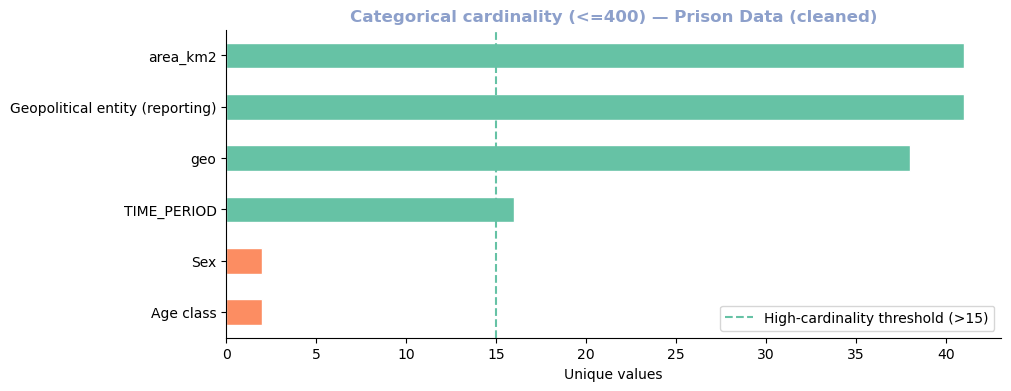

HIGH-CARDINALITY features (excluded from chart):
    'population_year': 580 unique values — needs grouping/target encoding
    'Total': 2336 unique values — needs grouping/target encoding
    'Per hundred thousand inhabitants': 2596 unique values — needs grouping/target encoding

  Reviewing unique values (Prison Data (cleaned)):
  'Age class' (2 values): ['Adult', 'Juvenile']

  'Sex' (2 values): ['Females', 'Males']

  'TIME_PERIOD' (16 values): ['2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']

  'geo' (38 values): ['ALB', 'AUT', 'BEL', 'BGR', 'BIH', 'CHE', 'CYP', 'CZE', 'DEU', 'DNK', 'ESP', 'EST', 'FIN', 'FRA', 'GRC', 'HRV', 'HUN', 'IRL', 'ISL', 'ITA', 'LIE', 'LTU', 'LUX', 'LVA', 'MKD', 'MLT', 'MNE', 'NLD', 'NOR', 'POL', 'PRT', 'ROU', 'SRB', 'SVK', 'SVN', 'SWE', 'TUR', 'XKX']

  'Geopolitical entity (reporting)' (41 values): ['Albania', 'Austria', 'Belgium', 'Bosnia and Herzegovina', 'Bulgaria', 'Croatia

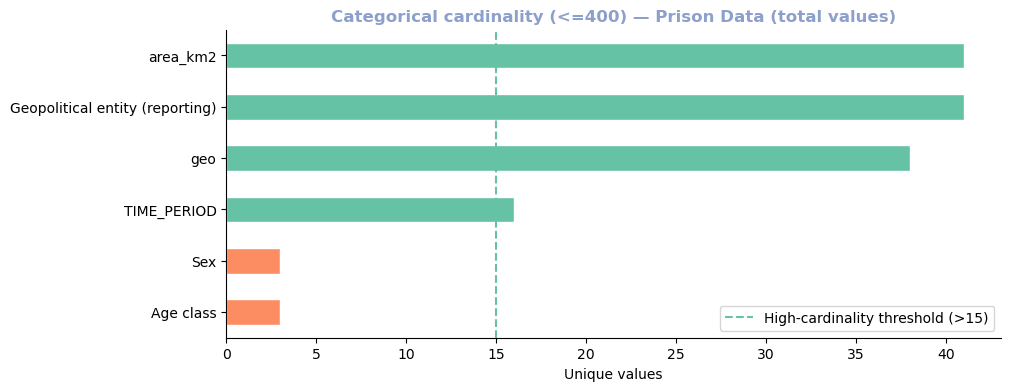

HIGH-CARDINALITY features (excluded from chart):
    'population_year': 590 unique values — needs grouping/target encoding
    'Total': 4095 unique values — needs grouping/target encoding
    'Per hundred thousand inhabitants': 4530 unique values — needs grouping/target encoding

  Reviewing unique values (Prison Data (total values)):
  'Age class' (3 values): ['Adult', 'Juvenile', 'Total']

  'Sex' (3 values): ['Females', 'Males', 'Total']

  'TIME_PERIOD' (16 values): ['2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']

  'geo' (38 values): ['ALB', 'AUT', 'BEL', 'BGR', 'BIH', 'CHE', 'CYP', 'CZE', 'DEU', 'DNK', 'ESP', 'EST', 'FIN', 'FRA', 'GRC', 'HRV', 'HUN', 'IRL', 'ISL', 'ITA', 'LIE', 'LTU', 'LUX', 'LVA', 'MKD', 'MLT', 'MNE', 'NLD', 'NOR', 'POL', 'PRT', 'ROU', 'SRB', 'SVK', 'SVN', 'SWE', 'TUR', 'XKX']

  'Geopolitical entity (reporting)' (41 values): ['Albania', 'Austria', 'Belgium', 'Bosnia and Herzegovina

In [430]:
inspect_categorical(prison_data, "Prison Data (cleaned)")
inspect_categorical(total_values, "Prison Data (total values)")

In [431]:
# Save the cleaned dataset in Data to export folder
prison_data.to_csv('../data/Data to export//cleaned_prison_data.csv', index=False)
total_values.to_csv('../data/Data to export//total_values_prison_data.csv', index=False)